# Logistic Regression Project: Ad Click Prediction

## Project Description

This project uses **Logistic Regression** to build a binary classification model that predicts whether an internet user will click on an online advertisement based on their behavioral and demographic characteristics.

## Dataset

The dataset contains information about 1,000 internet users with the following features:

- **Daily Time Spent on Site** - Minutes user spends on the site
- **Age** - User's age in years
- **Area Income** - Average income of user's geographical area
- **Daily Internet Usage** - Average daily internet usage in minutes
- **Ad Topic Line** - Headline of the advertisement
- **City** - User's city
- **Male** - Gender indicator (1 for male, 0 for female)
- **Country** - User's country
- **Timestamp** - Time when user clicked ad or closed window
- **Clicked on Ad** - Target variable (0 = No click, 1 = Click)

## Objective

Build a predictive model that accurately determines whether a user will click on an advertisement, enabling businesses to target the right audience and optimize advertising budgets.

## Approach

1. **Data Exploration** - Analyze patterns, distributions, and relationships between features and ad clicks
2. **Data Preprocessing** - Select relevant features and scale numerical variables
3. **Model Training** - Train a Logistic Regression model on the dataset
4. **Model Evaluation** - Assess performance using accuracy, confusion matrix, precision, recall, and F1-score
5. **Interpretation** - Identify which features most influence click behavior

## Expected Outcomes

- A trained logistic regression model with high accuracy
- Identification of key factors driving ad clicks (e.g., time spent on site, age, internet usage)
- Actionable insights for targeted advertising strategies

## Key Skills Applied

- Binary classification with logistic regression
- Exploratory data analysis and visualization
- Feature scaling and data splitting
- Model evaluation metrics interpretation
- Business insight generation from model coefficients

In [2]:
# Core Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Model Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# To avoid unusual error
import warnings
warnings.filterwarnings('ignore')

# **Loading Dataset** and seeing basic info..

In [4]:
df=pd.read_csv('advertising.csv')

In [5]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   str    
 5   City                      1000 non-null   str    
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   str    
 8   Timestamp                 1000 non-null   str    
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), str(4)
memory usage: 78.3 KB


## **Exploratory Data Analysis**

In [8]:
# checking for null values
null= df.isnull().sum().sum()
# checking for duplicates value
dup= df.duplicated().sum()
# checking shape of the dataset
shape=df.shape

print(f'Total null value: {null}')
print(f'Total Duplicates value: {dup}')
print(f'Shape of the dataset: {shape}')

#renaming male column as Gender where male=1,female=0
df.rename(columns={
    'Male':'Gender'
}, inplace=True)

Total null value: 0
Total Duplicates value: 0
Shape of the dataset: (1000, 10)


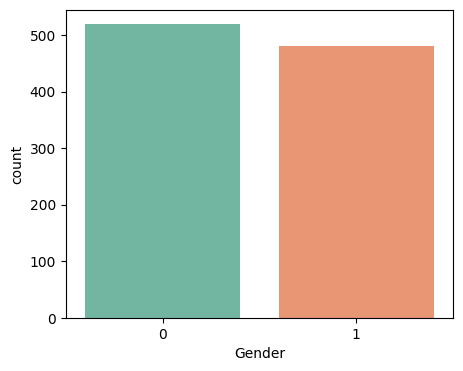

In [9]:
# making countplot to see the gender difference
plt.figure(figsize=(5,4))
sns.countplot(x=df['Gender'], palette='Set2')
plt.show()

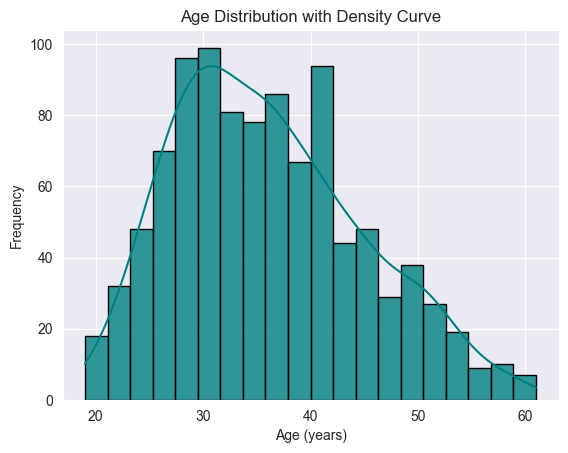

In [10]:
# making histogram to see age distribution 
sns.set_style("darkgrid")
sns.histplot(df['Age'], edgecolor='black', alpha=0.8, kde=True, bins=20, color='teal')
plt.title('Age Distribution with Density Curve')
plt.xlabel('Age (years)')
plt.ylabel('Frequency')
plt.show()

<Figure size 1200x500 with 0 Axes>

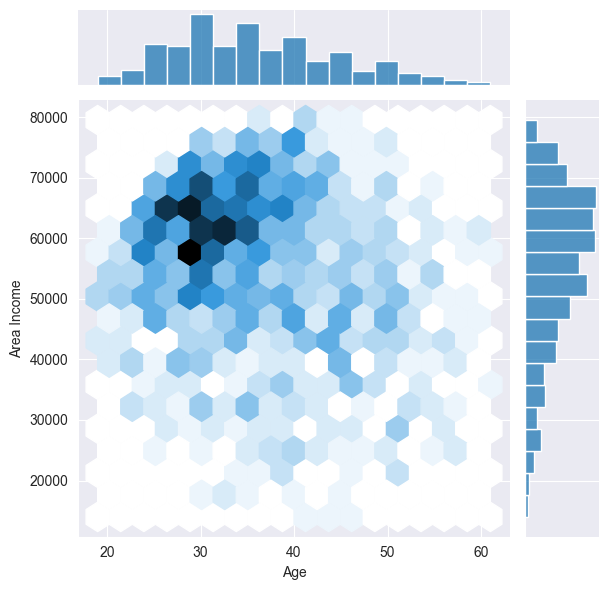

In [11]:
# Creating joitplot to see the effect of income and age on one oanother.
sns.jointplot(x='Age', y='Area Income', data=df, kind='hex')
plt.show()

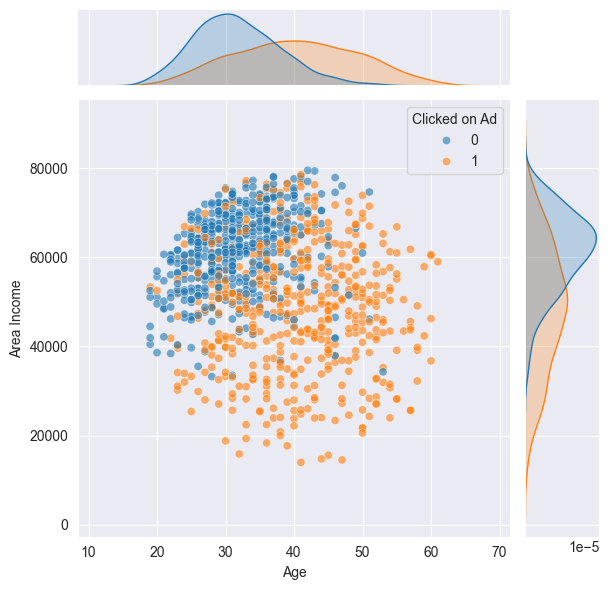

In [12]:
# Creating jointplot with adding Clicked hue....
sns.set_style("darkgrid")
sns.jointplot(x='Age', y='Area Income', data=df, hue='Clicked on Ad', alpha=0.6)
plt.show()

<Figure size 1600x400 with 0 Axes>

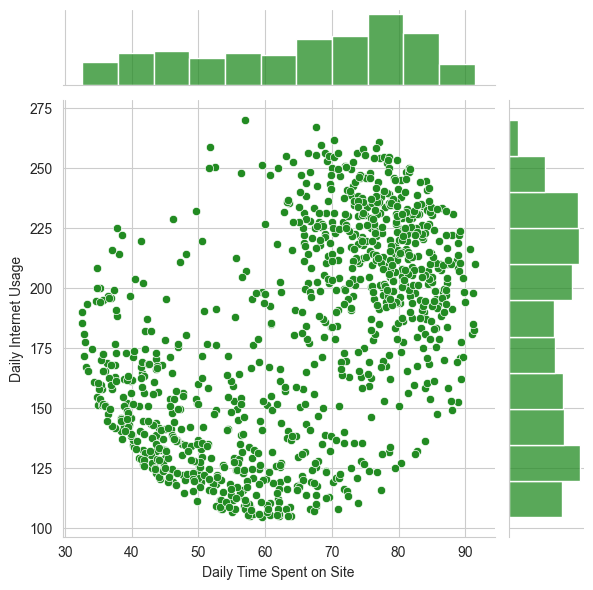

In [14]:
#Creating jointplot to see the effect of Daily Internet use and Daily time spent on site....

plt.figure(figsize=(16,4))
sns.set_style("whitegrid")
sns.jointplot(x='Daily Time Spent on Site',y='Daily Internet Usage',data=df,color='forestgreen')
plt.show()

In [ ]:
sns.pairplot(df, hue='Clicked on Ad', diag_kind='hist', palette='Set1')
plt.show()

## Creating a correlation heatmap to analyse the correlation among features.

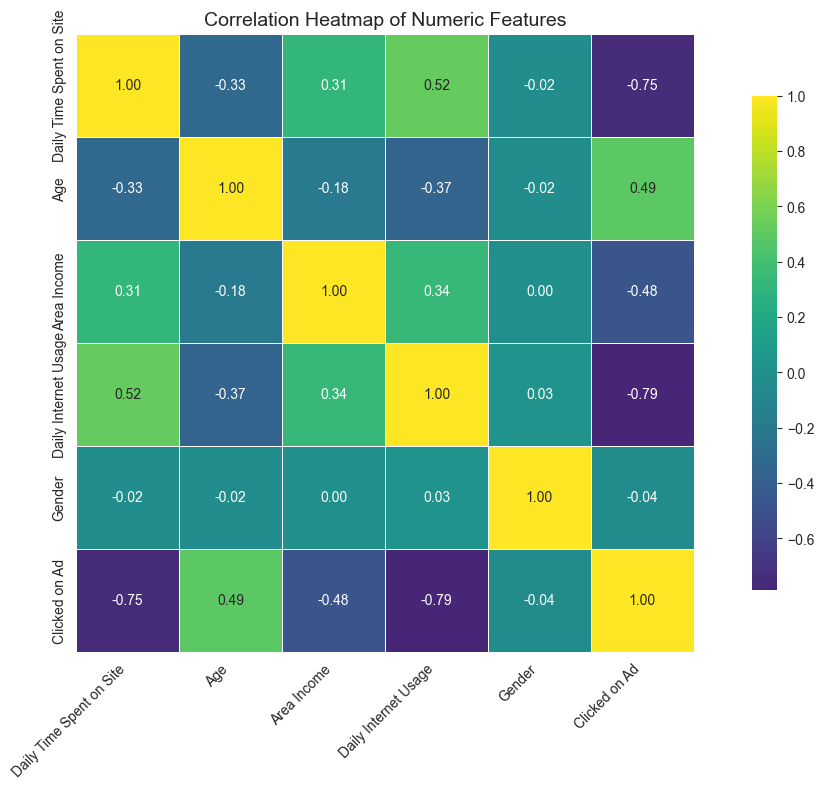

In [18]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64'])

# Calculate correlation matrix
correlation_matrix = numeric_cols.corr()

# Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix,
            annot=True,           # Show correlation values
            cmap='viridis',      # Color scheme
            center=0,             # Center colormap at 0
            fmt='.2f',            # 2 decimal places
            linewidths=0.5,       # Grid lines
            square=True,          # Square cells
            cbar_kws={'shrink': 0.8})  # Colorbar size
plt.title('Correlation Heatmap of Numeric Features', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Spliting the dataset and Feature scaling

In [19]:
# Import train_test_split if not already imported...
# Splitting the data
x = df.drop(columns=['Ad Topic Line', 'Country', 'City', 'Timestamp','Clicked on Ad'])  # These are complex feature and does not have signifacant correlation.
y = df['Clicked on Ad'] #our prediction feature

# Scale only the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x=x_scaled
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=101)

## Model making and prediction

In [20]:
model=LogisticRegression()
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [21]:
y_pred= model.predict(x_test)

## Model evaluation

In [22]:
accuracy= accuracy_score(y_test,y_pred)
print(f"The accuracy on test data is: {accuracy*100}%")
# model is looking very good

The accuracy on test data is: 98.0%


In [23]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       105
           1       1.00      0.96      0.98        95

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200

[[105   0]
 [  4  91]]


 # ** Building a predictive system**

In [ ]:
# Get input values from user
print("Enter the following values:")
daily_time = float(input("Daily Time Spent on Site: "))
age = float(input("Age: "))
area_income = float(input("Area Income: "))
daily_internet = float(input("Daily Internet Usage: "))
male = float(input("Male (1 for Yes, 0 for No): "))

# Create input data
input_data = [daily_time, age, area_income, daily_internet, male] # It will be filled by the user input

# Changing the input_data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# Reshape the np array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# Scale the input (IMPORTANT: use the same scaler you trained with)
input_data_scaled = scaler.transform(input_data_reshaped)

# Predicting
prediction = model.predict(input_data_scaled)

# Output
print("\n" + "="*30)
if prediction[0] == 1:
    print("The user will CLICK on the ad")
else:
    print("The user will NOT click on the ad")
print("="*30)

### It was a cool projects..... accuracy was very good
#### Follow me on github to find more projects: https://github.com/siumahameed
## Thank You